# 

# Leitura do CSV para dataframe

In [1]:
import polars as pl

df = pl.read_csv("flights.csv")

# Preparação da tabela para análises

In [2]:
def hhmm_to_duration(col_name):
    """Convert an HHMM integer (e.g. 5 → 00:05, 2354 → 23:54) to a Polars duration."""
    val = pl.col(col_name).cast(pl.Int64)
    return pl.duration(hours=val // 100, minutes=val % 100)

In [ ]:
# Tratamento de datas e horas int usando Polars
base_date = pl.date(pl.col("YEAR"), pl.col("MONTH"), pl.col("DAY")).cast(pl.Datetime("us"))
df = (
    df
    # 1. Scheduled departure: base date + HHMM offset
    .with_columns(
        (base_date + hhmm_to_duration("SCHEDULED_DEPARTURE")).alias("SCHEDULED_DEPARTURE_DT")
    )
    # 2. Actual departure and scheduled arrival (both derived from scheduled departure)
    .with_columns(
        (pl.col("SCHEDULED_DEPARTURE_DT") + pl.duration(minutes=pl.col("DEPARTURE_DELAY").cast(pl.Int64))).alias("DEPARTURE_TIME_DT"),
        (pl.col("SCHEDULED_DEPARTURE_DT") + pl.duration(minutes=pl.col("SCHEDULED_TIME").cast(pl.Int64))).alias("SCHEDULED_ARRIVAL_DT"),
    )
    # 3. Wheels off: actual departure + taxi out
    .with_columns(
        (pl.col("DEPARTURE_TIME_DT") + pl.duration(minutes=pl.col("TAXI_OUT").cast(pl.Int64))).alias("WHEELS_OFF_DT"),
    )
    # 4. Wheels on: wheels off + air time
    .with_columns(
        (pl.col("WHEELS_OFF_DT") + pl.duration(minutes=pl.col("AIR_TIME").cast(pl.Int64))).alias("WHEELS_ON_DT"),
    )
    # 5. Actual arrival: scheduled arrival + arrival delay
    .with_columns(
        (pl.col("SCHEDULED_ARRIVAL_DT") + pl.duration(minutes=pl.col("ARRIVAL_DELAY").cast(pl.Int64))).alias("ARRIVAL_TIME_DT"),
    )
)

int_time_cols = [
    "SCHEDULED_DEPARTURE",
    "DEPARTURE_TIME",
    "WHEELS_OFF",
    "WHEELS_ON",
    "SCHEDULED_ARRIVAL",
    "ARRIVAL_TIME",
]

rename_map = {f"{c}_DT": c for c in int_time_cols}

# Alocação das colunas timestamp no lugar das colunas originais de tempo, mantendo a ordem original das colunas
original_order = [c for c in df.columns if not c.endswith("_DT")]

df = (
    df
    .drop(int_time_cols)
    .rename(rename_map)
    .select(original_order)
    .drop(["YEAR", "MONTH", "DAY"])
)

# Categorizando dias da semana e outras colunas
df = df.with_columns(
    pl.col("DAY_OF_WEEK")
    .replace_strict([1, 2, 3, 4, 5, 6, 7], ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"], return_dtype=pl.String)
)

df = df.with_columns(
    pl.col("FLIGHT_NUMBER").cast(pl.String).cast(pl.Categorical),
    pl.col("CANCELLED").cast(pl.String).cast(pl.Categorical)
)

df.head()

DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
str,str,cat,str,str,str,datetime[μs],datetime[μs],i64,i64,datetime[μs],i64,i64,i64,i64,datetime[μs],i64,datetime[μs],datetime[μs],i64,i64,cat,str,i64,i64,i64,i64,i64
"""Wed""","""AS""","""98""","""N407AS""","""ANC""","""SEA""",2015-01-01 00:05:00,2014-12-31 23:54:00,-11,21,2015-01-01 00:15:00,205,194,169,1448,2015-01-01 03:04:00,4,2015-01-01 03:30:00,2015-01-01 03:08:00,-22,0,"""0""",null,null,null,null,null,null
"""Wed""","""AA""","""2336""","""N3KUAA""","""LAX""","""PBI""",2015-01-01 00:10:00,2015-01-01 00:02:00,-8,12,2015-01-01 00:14:00,280,279,263,2330,2015-01-01 04:37:00,4,2015-01-01 04:50:00,2015-01-01 04:41:00,-9,0,"""0""",null,null,null,null,null,null
"""Wed""","""US""","""840""","""N171US""","""SFO""","""CLT""",2015-01-01 00:20:00,2015-01-01 00:18:00,-2,16,2015-01-01 00:34:00,286,293,266,2296,2015-01-01 05:00:00,11,2015-01-01 05:06:00,2015-01-01 05:11:00,5,0,"""0""",null,null,null,null,null,null
"""Wed""","""AA""","""258""","""N3HYAA""","""LAX""","""MIA""",2015-01-01 00:20:00,2015-01-01 00:15:00,-5,15,2015-01-01 00:30:00,285,281,258,2342,2015-01-01 04:48:00,8,2015-01-01 05:05:00,2015-01-01 04:56:00,-9,0,"""0""",null,null,null,null,null,null
"""Wed""","""AS""","""135""","""N527AS""","""SEA""","""ANC""",2015-01-01 00:25:00,2015-01-01 00:24:00,-1,11,2015-01-01 00:35:00,235,215,199,1448,2015-01-01 03:54:00,5,2015-01-01 04:20:00,2015-01-01 03:59:00,-21,0,"""0""",null,null,null,null,null,null


# Dataframe com voos não cancelados

In [6]:
df_not_cancelled = df.filter(pl.col("CANCELLATION_REASON").is_null())

df_not_cancelled.head()

DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
str,str,cat,str,str,str,datetime[μs],datetime[μs],i64,i64,datetime[μs],i64,i64,i64,i64,datetime[μs],i64,datetime[μs],datetime[μs],i64,i64,cat,str,i64,i64,i64,i64,i64
"""Wed""","""AS""","""98""","""N407AS""","""ANC""","""SEA""",2015-01-01 00:05:00,2014-12-31 23:54:00,-11,21,2015-01-01 00:15:00,205,194,169,1448,2015-01-01 03:04:00,4,2015-01-01 03:30:00,2015-01-01 03:08:00,-22,0,"""0""",null,null,null,null,null,null
"""Wed""","""AA""","""2336""","""N3KUAA""","""LAX""","""PBI""",2015-01-01 00:10:00,2015-01-01 00:02:00,-8,12,2015-01-01 00:14:00,280,279,263,2330,2015-01-01 04:37:00,4,2015-01-01 04:50:00,2015-01-01 04:41:00,-9,0,"""0""",null,null,null,null,null,null
"""Wed""","""US""","""840""","""N171US""","""SFO""","""CLT""",2015-01-01 00:20:00,2015-01-01 00:18:00,-2,16,2015-01-01 00:34:00,286,293,266,2296,2015-01-01 05:00:00,11,2015-01-01 05:06:00,2015-01-01 05:11:00,5,0,"""0""",null,null,null,null,null,null
"""Wed""","""AA""","""258""","""N3HYAA""","""LAX""","""MIA""",2015-01-01 00:20:00,2015-01-01 00:15:00,-5,15,2015-01-01 00:30:00,285,281,258,2342,2015-01-01 04:48:00,8,2015-01-01 05:05:00,2015-01-01 04:56:00,-9,0,"""0""",null,null,null,null,null,null
"""Wed""","""AS""","""135""","""N527AS""","""SEA""","""ANC""",2015-01-01 00:25:00,2015-01-01 00:24:00,-1,11,2015-01-01 00:35:00,235,215,199,1448,2015-01-01 03:54:00,5,2015-01-01 04:20:00,2015-01-01 03:59:00,-21,0,"""0""",null,null,null,null,null,null


# Distribuição dos tempos de atraso de forma geral
O critério para considerar um atraso é o voo que chegou no destino com mais de 30 min além do previsto.

## Quantidade de missing values dentre os voo não cancelados

In [ ]:
# Análise de valores ausentes na coluna ARRIVAL_DELAY para voos não cancelados
missing = df_not_cancelled["ARRIVAL_DELAY"].is_null().sum()
total   = len(df_not_cancelled)

# missing values é menos que 1% da amostra, então vamos ignorá-los para esta análise.
print(f"Missing: {missing:,} / {total:,} ({missing / total * 100:.2f}%)")

Missing: 15,187 / 5,729,195 (0.27%)


# Total de voos por companhia.

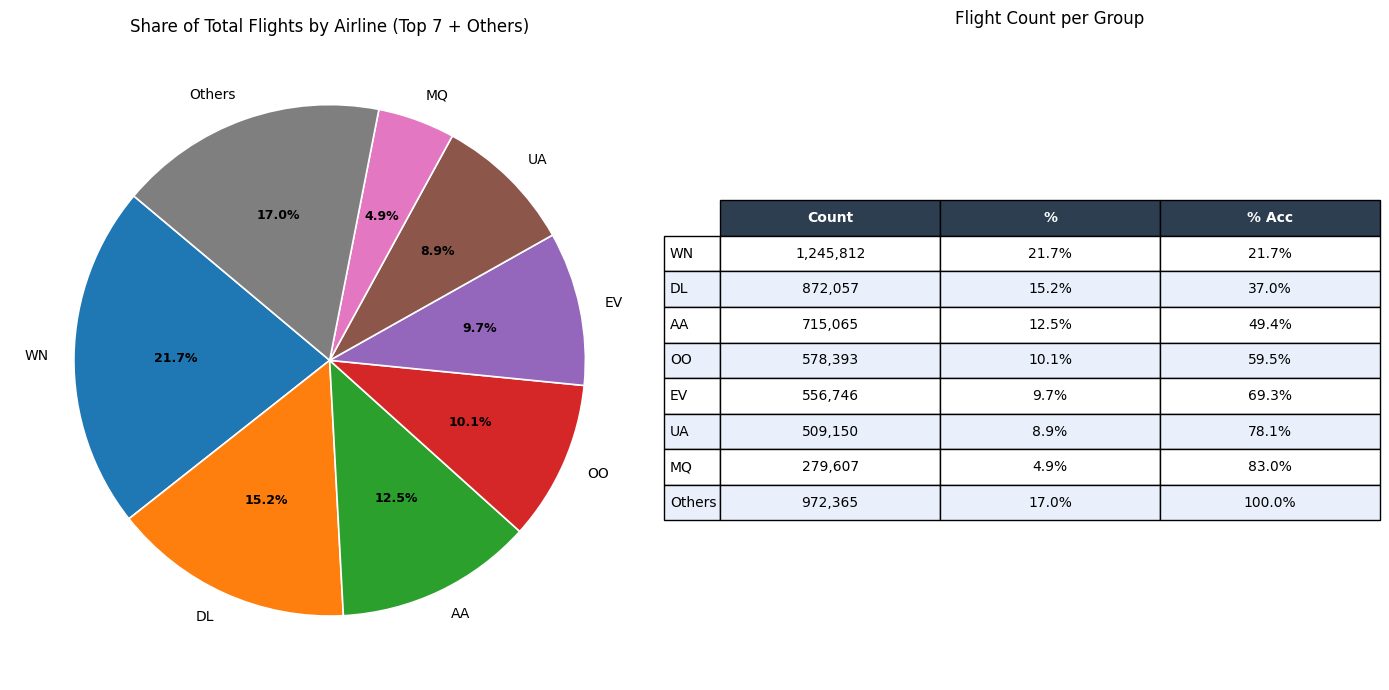

In [ ]:
import matplotlib.pyplot as plt

flight_counts = (
    df_not_cancelled
    .group_by("AIRLINE")
    .agg(pl.len().alias("COUNT"))
    .sort("COUNT", descending=True)
)

top7   = flight_counts.head(7)
others = flight_counts.tail(len(flight_counts) - 7)

labels = top7["AIRLINE"].to_list() + ["Others"]
sizes  = top7["COUNT"].to_list()   + [others["COUNT"].sum()]

total  = sum(sizes)
pcts   = [s / total * 100 for s in sizes]
acc    = []
cum    = 0.0
for p in pcts:
    cum += p
    acc.append(cum)

fig, (ax_pie, ax_tbl) = plt.subplots(1, 2, figsize=(14, 7),
                                      gridspec_kw={"width_ratios": [1.2, 1]})

wedges, texts, autotexts = ax_pie.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=plt.cm.tab10.colors[:len(labels)],
    wedgeprops=dict(edgecolor="white", linewidth=1.2),
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight("bold")
ax_pie.set_title("Share of Total Flights by Airline (Top 7 + Others)")

table_data = [
    [f"{c:,}", f"{p:.1f}%", f"{a:.1f}%"]
    for c, p, a in zip(sizes, pcts, acc)
]

tbl = ax_tbl.table(
    cellText=table_data,
    rowLabels=labels,
    colLabels=["Count", "%", "% Acc"],
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)

# header styling
for col in range(3):
    tbl[0, col].set_facecolor("#2c3e50")
    tbl[0, col].set_text_props(color="white", fontweight="bold")

# row label styling + alternating row colors
for row in range(1, len(labels) + 1):
    bg = "#eaf0fb" if row % 2 == 0 else "white"
    tbl[row, -1].set_facecolor(bg)   # row label cell
    for col in range(3):
        tbl[row, col].set_facecolor(bg)

ax_tbl.axis("off")
ax_tbl.set_title("Flight Count per Group", pad=12)

plt.tight_layout()
plt.show()

## Analise estatística dos voos atrasados

In [ ]:
# dataframe contendo apenas os atrasos.
delay_series = (
    df_not_cancelled
    .filter(pl.col("ARRIVAL_DELAY") > 30)
    .select("ARRIVAL_DELAY")
    .drop_nulls()
)

# Proporção de voos atrasados (ARRIVAL_DELAY > 30 minutos)
portion = len(delay_series) / len(df_not_cancelled) * 100
print(f"Portion of delayed flights: {portion:.2f}%")

# Estatísticas descritivas para a coluna ARRIVAL_DELAY
summary = delay_series.select(
    pl.col("ARRIVAL_DELAY").count().alias("Count"),
    pl.col("ARRIVAL_DELAY").mean().alias("Mean"),
    pl.col("ARRIVAL_DELAY").median().alias("Median"),
    pl.col("ARRIVAL_DELAY").std().alias("Std Dev"),
    pl.col("ARRIVAL_DELAY").min().alias("Min"),
    pl.col("ARRIVAL_DELAY").max().alias("Max"),
    pl.col("ARRIVAL_DELAY").quantile(0.25).alias("Q1 (25%)"),
    pl.col("ARRIVAL_DELAY").quantile(0.75).alias("Q3 (75%)"),
    pl.col("ARRIVAL_DELAY").skew().alias("Skewness"),
    pl.col("ARRIVAL_DELAY").kurtosis().alias("Kurtosis"),
)

print(summary.transpose(include_header=True, header_name="Statistic", column_names=["Value"]))

Portion of delayed flights: 11.04%
shape: (10, 2)
┌───────────┬───────────┐
│ Statistic ┆ Value     │
│ ---       ┆ ---       │
│ str       ┆ f64       │
╞═══════════╪═══════════╡
│ Count     ┆ 632697.0  │
│ Mean      ┆ 84.485936 │
│ Median    ┆ 61.0      │
│ Std Dev   ┆ 72.870236 │
│ Min       ┆ 31.0      │
│ Max       ┆ 1971.0    │
│ Q1 (25%)  ┆ 42.0      │
│ Q3 (75%)  ┆ 100.0     │
│ Skewness  ┆ 4.683755  │
│ Kurtosis  ┆ 44.39898  │
└───────────┴───────────┘


## Distribuição dos tempos de atraso

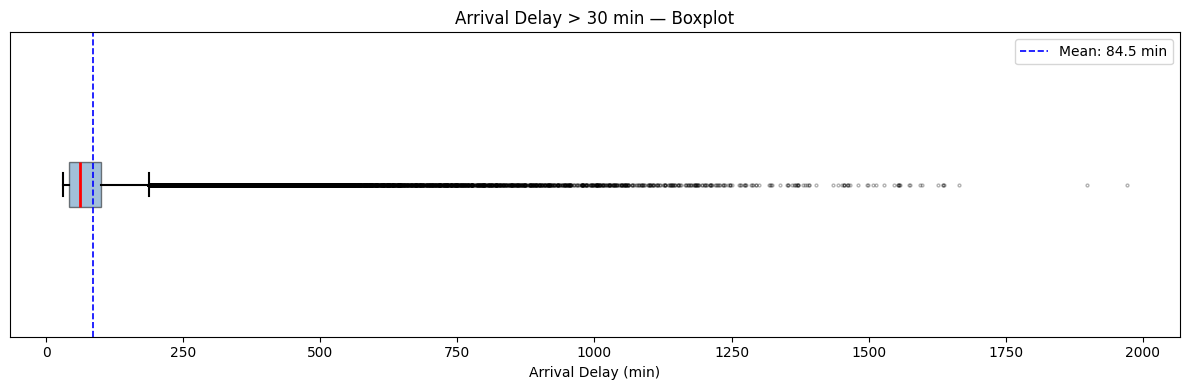

In [8]:
data   = delay_series["ARRIVAL_DELAY"].to_numpy()
mean   = float(summary["Mean"][0])
median = float(summary["Median"][0])
q1     = float(summary["Q1 (25%)"][0])
q3     = float(summary["Q3 (75%)"][0])

fig, ax = plt.subplots(figsize=(12, 4))
bp = ax.boxplot(data, vert=False, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.5),
                medianprops=dict(color="red", lw=2),
                whiskerprops=dict(lw=1.5),
                capprops=dict(lw=1.5),
                flierprops=dict(marker="o", markersize=2, alpha=0.3, color="gray"))
ax.axvline(mean, color="blue", linestyle="--", lw=1.2, label=f"Mean: {mean:.1f} min")
ax.set_xlabel("Arrival Delay (min)")
ax.set_title("Arrival Delay > 30 min — Boxplot")
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()

### Observações
Dentre os voos considerados, sendo 11% da amostra, temos:
- 25% (Q1) tem atraso até 42min
- 50% (Q2 - mediana) tem atraso de até 61min
- 75% (Q3) tem atraso de até 100min

Também é possível obeservar uma quantidade considerável de outliers na amostra.

Sendo a média e o desvio padrão 85min e 73min respectivamente, 97,72% das amostras (μ + 2 $\sigma$), ficaram abaixo de 231min de atraso (3,85h)

A assimetria (skewness) positiva também indica cauda longa a direita, ou seja, concentração das amostras a esquerda da média.
Já a curtose leptocurtica indica concentração das amostras concentradas próxima à média.

# Atrasos por frequência de ocorrência por companhia

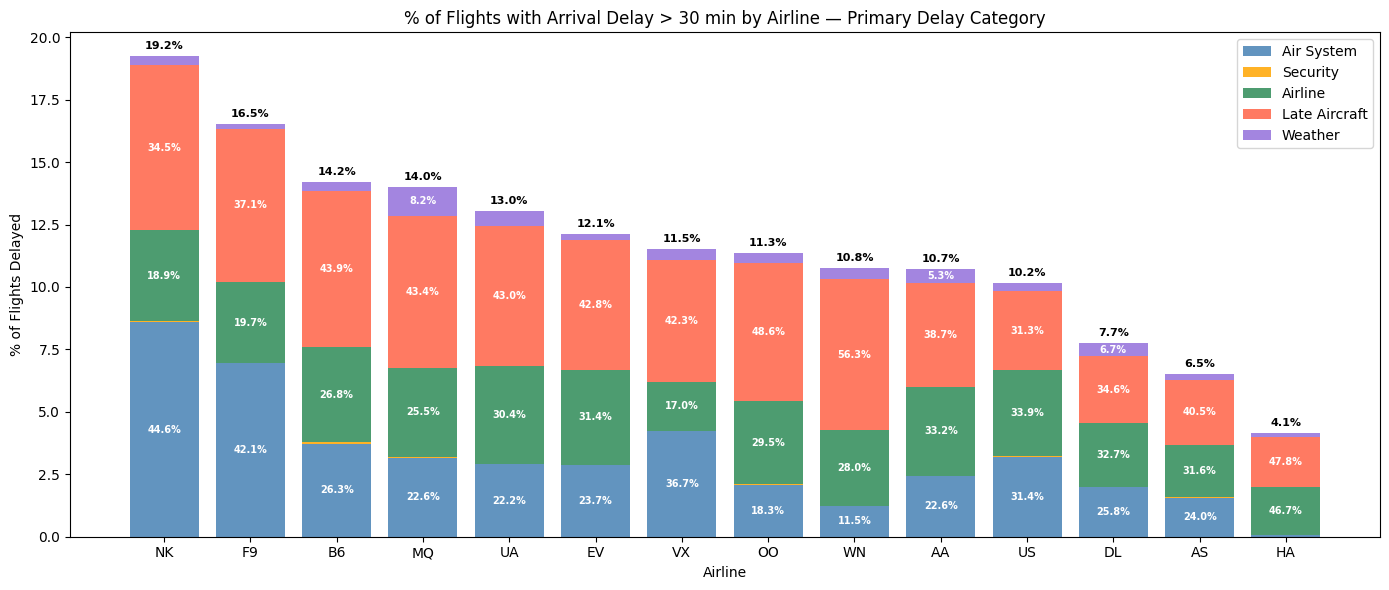

In [14]:
import matplotlib.pyplot as plt
import numpy as np

delay_cols   = ["AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY"]
delay_labels = ["Air System", "Security", "Airline", "Late Aircraft", "Weather"]
delay_colors = ["steelblue", "orange", "seagreen", "tomato", "mediumpurple"]

total_per_airline = (
    df_not_cancelled
    .group_by("AIRLINE")
    .agg(pl.len().alias("TOTAL"))
)

# For each delayed flight, pick the category with the highest value as the primary reason.
# Ties are broken by column order. Flights where all columns are 0/null → "Unknown".
df_delayed = (
    df_not_cancelled
    .filter(pl.col("ARRIVAL_DELAY") > 30)
    .with_columns([pl.col(c).fill_null(0) for c in delay_cols])
    .with_columns(
        pl.max_horizontal(*[pl.col(c) for c in delay_cols]).alias("_MAX_VAL")
    )
    .with_columns(
        pl.when((pl.col("AIR_SYSTEM_DELAY")  == pl.col("_MAX_VAL")) & (pl.col("_MAX_VAL") > 0)).then(pl.lit("Air System"))
        .when((pl.col("SECURITY_DELAY")       == pl.col("_MAX_VAL")) & (pl.col("_MAX_VAL") > 0)).then(pl.lit("Security"))
        .when((pl.col("AIRLINE_DELAY")         == pl.col("_MAX_VAL")) & (pl.col("_MAX_VAL") > 0)).then(pl.lit("Airline"))
        .when((pl.col("LATE_AIRCRAFT_DELAY")   == pl.col("_MAX_VAL")) & (pl.col("_MAX_VAL") > 0)).then(pl.lit("Late Aircraft"))
        .when((pl.col("WEATHER_DELAY")         == pl.col("_MAX_VAL")) & (pl.col("_MAX_VAL") > 0)).then(pl.lit("Weather"))
        .otherwise(pl.lit("Unknown"))
        .alias("PRIMARY_DELAY")
    )
    .drop("_MAX_VAL")
)

delayed_per_airline = (
    df_delayed
    .group_by("AIRLINE")
    .agg(pl.len().alias("DELAYED"))
)

df_count = (
    df_delayed
    .group_by(["AIRLINE", "PRIMARY_DELAY"])
    .agg(pl.len().alias("COUNT"))
    .join(total_per_airline,   on="AIRLINE")
    .join(delayed_per_airline, on="AIRLINE")
    .with_columns(
        # bar height: segment as % of airline's total flights
        (pl.col("COUNT") / pl.col("TOTAL")   * 100).alias("PCT_OF_TOTAL"),
        # label: segment as % of airline's own delayed flights
        (pl.col("COUNT") / pl.col("DELAYED") * 100).alias("PCT_OF_DELAYED"),
    )
)

airline_totals = (
    df_count
    .group_by("AIRLINE")
    .agg(pl.col("PCT_OF_TOTAL").sum().alias("TOTAL_PCT"))
    .sort("TOTAL_PCT", descending=True)
)
airlines_sorted = airline_totals["AIRLINE"].to_list()

has_unknown    = "Unknown" in df_count["PRIMARY_DELAY"].to_list()
all_categories = delay_labels + (["Unknown"] if has_unknown else [])
all_colors     = delay_colors  + (["gray"]    if has_unknown else [])

height_map = {(r["AIRLINE"], r["PRIMARY_DELAY"]): r["PCT_OF_TOTAL"]   for r in df_count.to_dicts()}
label_map  = {(r["AIRLINE"], r["PRIMARY_DELAY"]): r["PCT_OF_DELAYED"] for r in df_count.to_dicts()}
total_map  = {r["AIRLINE"]: r["TOTAL_PCT"] for r in airline_totals.to_dicts()}

fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(airlines_sorted))

for cat, color in zip(all_categories, all_colors):
    heights = np.array([height_map.get((a, cat), 0.0) for a in airlines_sorted], dtype=float)
    labels  = [label_map.get((a, cat), 0.0) for a in airlines_sorted]
    bars = ax.bar(airlines_sorted, heights, bottom=bottom, label=cat, color=color, alpha=0.85)
    for bar, h, lbl in zip(bars, heights, labels):
        if lbl >= 5.0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{lbl:.1f}%",
                ha="center", va="center", fontsize=7, color="white", fontweight="bold"
            )
    bottom += heights

for i, airline in enumerate(airlines_sorted):
    ax.text(i, bottom[i] + 0.2, f"{total_map[airline]:.1f}%",
            ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xlabel("Airline")
ax.set_ylabel("% of Flights Delayed")
ax.set_title("% of Flights with Arrival Delay > 30 min by Airline — Primary Delay Category")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


NK é a companhia que tem mais atrasos em relação ao número de voos realizados. 19% dos seus voos atrasam, seguida pela F9 e B6.
A principal ocorrência de atraso para NK é o Air System ja para a B6 a principal razão é o Late Aircraft.

# Análise dos tempos de atraso acumulados por companhia

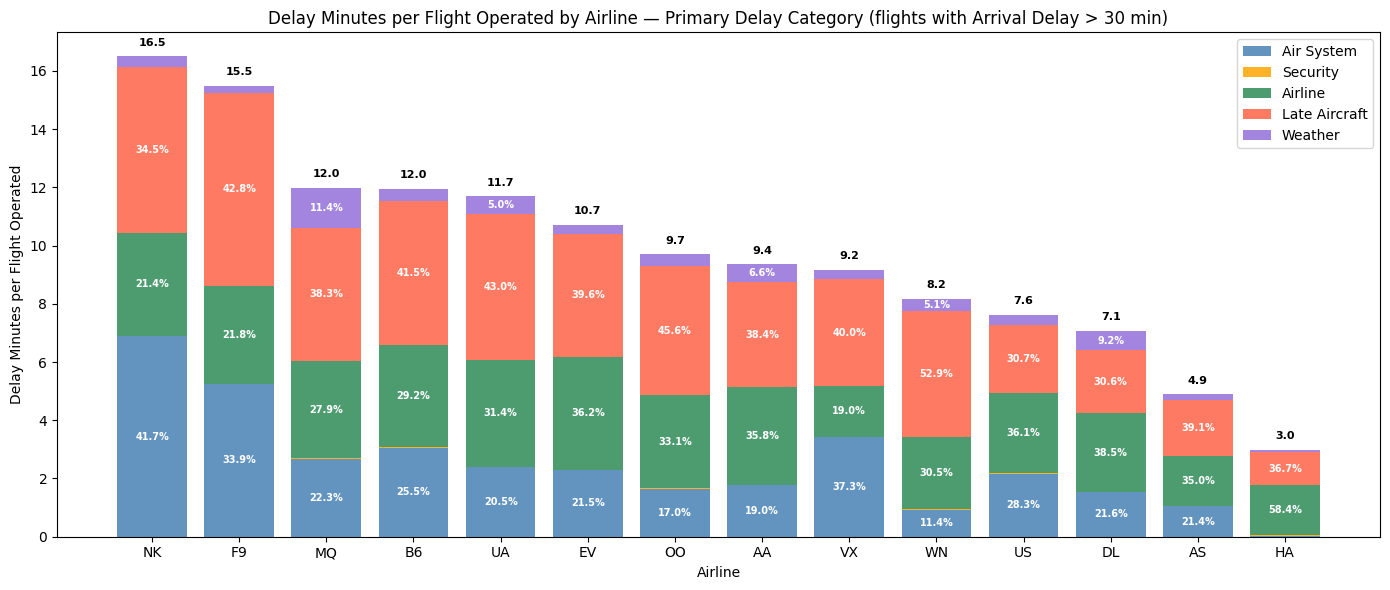

In [22]:
delay_cols = [
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY",
]

total_per_airline = (
    df_not_cancelled
    .group_by("AIRLINE")
    .agg(pl.len().alias("TOTAL_FLIGHTS"))
)

df_delay_breakdown = (
    df_not_cancelled
    .filter(pl.col("ARRIVAL_DELAY") > 30)
    .with_columns([pl.col(c).fill_null(0) for c in delay_cols])
    .group_by("AIRLINE")
    .agg([pl.col(c).sum() for c in delay_cols])
    .join(total_per_airline, on="AIRLINE")
    .with_columns(
        pl.sum_horizontal(*[pl.col(c) for c in delay_cols]).alias("TOTAL_DELAY")
    )
    .with_columns(
        [(pl.col(c) / pl.col("TOTAL_FLIGHTS")).alias(f"{c}_PER_FLIGHT") for c in delay_cols]
    )
    .with_columns(
        (pl.col("TOTAL_DELAY") / pl.col("TOTAL_FLIGHTS")).alias("TOTAL_DELAY_PER_FLIGHT")
    )
    .sort("TOTAL_DELAY_PER_FLIGHT", descending=True)
)

labels   = [c.replace("_DELAY", "").replace("_", " ").title() for c in delay_cols]
colors   = ["steelblue", "orange", "seagreen", "tomato", "mediumpurple"]
airlines = df_delay_breakdown["AIRLINE"].to_list()
bottom   = np.zeros(len(airlines))

fig, ax = plt.subplots(figsize=(14, 6))

for col, label, color in zip(delay_cols, labels, colors):
    vals = np.array(df_delay_breakdown[f"{col}_PER_FLIGHT"].to_list(), dtype=float)
    pcts = np.array([(v / t * 100) if t > 0 else 0
                     for v, t in zip(vals, df_delay_breakdown["TOTAL_DELAY_PER_FLIGHT"].to_list())], dtype=float)
    bars = ax.bar(airlines, vals, bottom=bottom, label=label, color=color, alpha=0.85)
    for bar, pct in zip(bars, pcts):
        if pct >= 5:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                    f"{pct:.1f}%", ha="center", va="center", fontsize=7, color="white", fontweight="bold")
    bottom += vals

for i, total in enumerate(df_delay_breakdown["TOTAL_DELAY_PER_FLIGHT"].to_list()):
    ax.text(i, bottom[i] + 0.3, f"{total:.1f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xlabel("Airline")
ax.set_ylabel("Delay Minutes per Flight Operated")
ax.set_title("Delay Minutes per Flight Operated by Airline — Primary Delay Category (flights with Arrival Delay > 30 min)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


o eixo Y é uma relação entre o total de minutos considerados atraso, ou seja, ARRIVAL_DELAY > 30min e o total de voos realizados pela companhia, sendo a NK é a empresa que se destaca nessa métrica.
A maior parte do tempo de atraso da NK deve-se ao fator Air System.

# Distribuição dos tempos de atraso por companhia

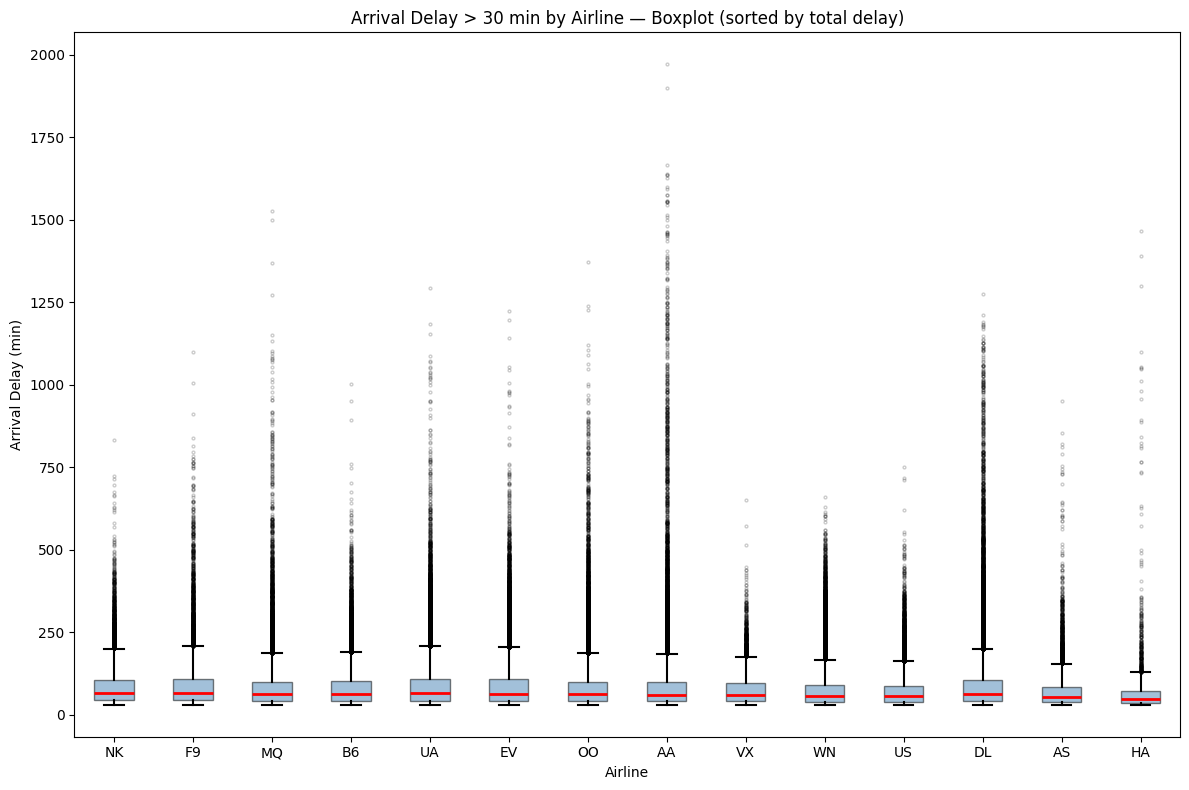

In [23]:
# Same airline order as the Delay Category Breakdown chart (sorted by total delay descending)
airlines = df_delay_breakdown["AIRLINE"].to_list()

data_by_airline = [
    df_not_cancelled
    .filter((pl.col("AIRLINE") == airline) & (pl.col("ARRIVAL_DELAY") > 30))
    ["ARRIVAL_DELAY"]
    .drop_nulls()
    .to_list()
    for airline in airlines
]

fig, ax = plt.subplots(figsize=(12, 8))
ax.boxplot(data_by_airline, vert=True, patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.5),
           medianprops=dict(color="red", lw=2),
           whiskerprops=dict(lw=1.5),
           capprops=dict(lw=1.5),
           flierprops=dict(marker="o", markersize=2, alpha=0.2, color="gray"))
ax.set_xticks(range(1, len(airlines) + 1))
ax.set_xticklabels(airlines)
ax.set_ylabel("Arrival Delay (min)")
ax.set_xlabel("Airline")
ax.set_title("Arrival Delay > 30 min by Airline — Boxplot (sorted by total delay)")
plt.tight_layout()
plt.show()


Apesar da métrica anterior apontando a NK como a que teria atrasos mais longos dentre seu total de voos realizados, percebesse que no geral todas as companhias possuem uma distribuição do tempo de atraso semelhante, porém fica evidente o número de outliers existente para a AA.